In [ ]:
# 1 & 2. Import libraries + Load Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

(X1, y1), (X2, y2) = tf.keras.datasets.mnist.load_data()

X = np.concatenate([X1, X2])
y = np.concatenate([y1, y2])

print("Dataset:", X.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset: (70000, 28, 28)


In [ ]:
# 3. EDA
print("\nClass Distribution:")

class_count = np.bincount(y)
for digit, count in enumerate(class_count):
    print(digit, ":", count)


Class Distribution:
0 : 6903
1 : 7877
2 : 6990
3 : 7141
4 : 6824
5 : 6313
6 : 6876
7 : 7293
8 : 6825
9 : 6958


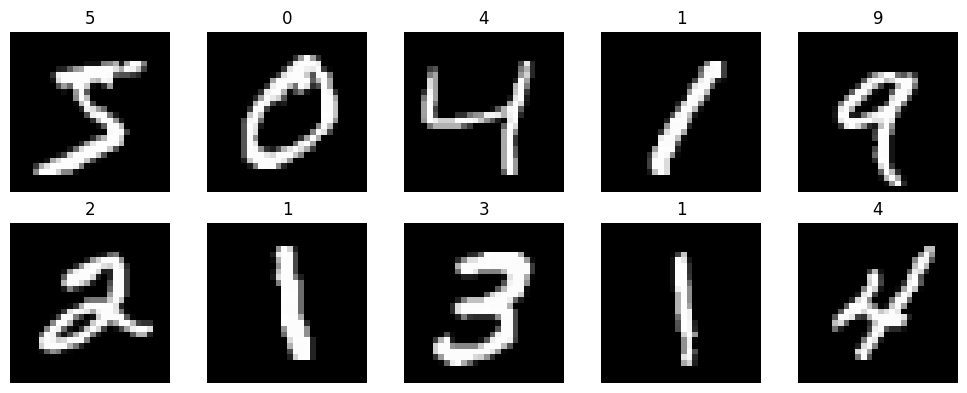

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(X[i], cmap="gray")
  plt.title(y[i])
  plt.axis("off")

plt.tight_layout()
plt.show()

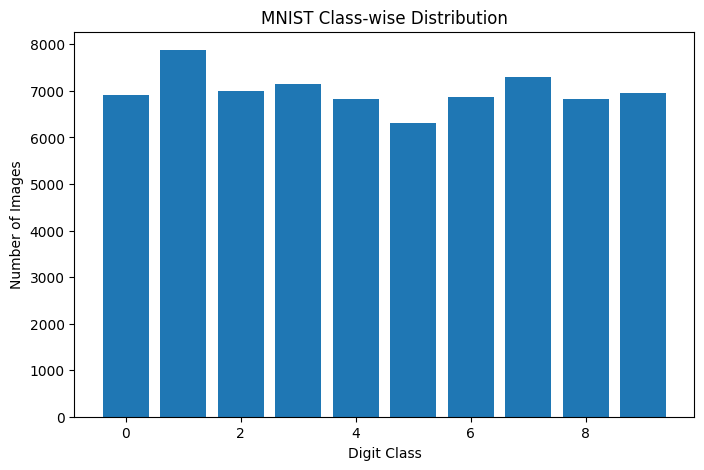

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(range(10), np.bincount(y))
plt.title("MNIST Class-wise Distribution")
plt.xlabel("Digit Class")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
def preprocess(X, y):
    X = X.astype("float32") / 255
    X = X.reshape(len(X), 784)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=.2, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=.5,random_state=42, stratify=y_temp)

    print("Train:",len(X_train),"| Validation:",len(X_val),"| Test:",len(X_test))
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = preprocess(X, y)

Train: 56000 | Validation: 7000 | Test: 7000


In [ ]:
def create_model(optimizer):
    model = Sequential([
        Input(shape=(784,)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])

    model.compile(optimizer=optimizer,loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    model.summary(line_length=60,positions=[0.3, 0.6, 0.75, 1.0])
    return model

In [ ]:
optimizers = {
    "GD": (SGD(learning_rate=0.01), len(X_train)),
    "Momentum Based GD": (SGD(learning_rate=0.01, momentum=0.9), 128),
    "Adam": (Adam(learning_rate=0.001), 128),
    "RMSprop": (RMSprop(learning_rate=0.001), 128)
}

In [ ]:
results = []
histories = {}
models = {}
for name, (optimizer, batch_size) in optimizers.items():
    print("\nTraining:", name)
    model = create_model(optimizer)
    history = model.fit(
        X_train, y_train,validation_data=(X_val, y_val),epochs=5,
        batch_size=batch_size,verbose=0
    )
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    models[name] = model
    histories[name] = history
    results.append([name,accuracy * 100,loss])
    print("Test Accuracy:", round(accuracy * 100, 2), "%")


Training: GD


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape         ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ dense (Dense)        │ (None, 128)          │    100,480 │
├──────────────────────┼──────────────────────┼────────────┤
│ dense_1 (Dense)      │ (None, 64)           │      8,256 │
├──────────────────────┼──────────────────────┼────────────┤
│ dense_2 (Dense)      │ (None, 10)           │        650 │
└──────────────────────┴──────────────────────┴────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape         ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ dense_9 (Dense)      │ (None, 128)          │    100,480 │
├──────────────────────┼──────────────────────┼────────────┤
│ dense_10 (Dense)     │ (None, 64)           │      8,256 │
├──────────────────────┼──────────────────────┼────────────┤
│ dense_11 (Dense)     │ (None, 10)           │        650 │
└──────────────────────┴──────────────────────┴────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Test Accuracy: 97.74 %


In [ ]:
results = pd.DataFrame(results,columns=["Optimizer", "Accuracy (%)", "Loss"])
print(results)

           Optimizer  Accuracy (%)      Loss
0                 GD     12.257143  2.338322
1  Momentum Based GD     96.714288  0.109780
2               Adam     97.657144  0.079935
3            RMSprop     97.742856  0.080247


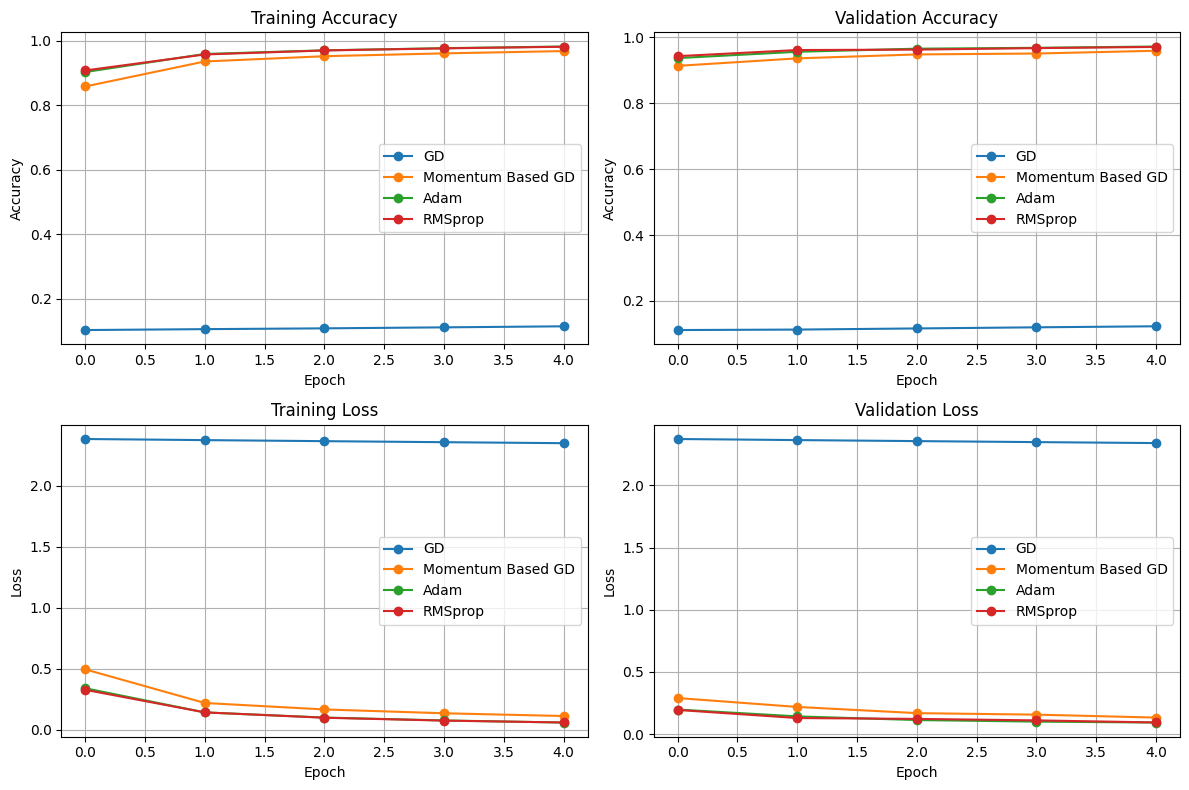

In [ ]:
def plot_graphs(histories):
    metrics = [
        ("accuracy", "Training Accuracy"),
        ("val_accuracy", "Validation Accuracy"),
        ("loss", "Training Loss"),
        ("val_loss", "Validation Loss")
    ]
    plt.figure(figsize=(12, 8))
    for i, (metric, title) in enumerate(metrics, 1):
        plt.subplot(2, 2, i)
        for name, history in histories.items():
            plt.plot(history.history[metric],marker="o",label=name)

        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy" if "accuracy" in metric else "Loss")
        plt.legend()
        plt.grid()

    plt.tight_layout()
    plt.show()

plot_graphs(histories)

In [ ]:
best = results.loc[results["Accuracy (%)"].idxmax()]

print("\nBest Optimizer:", best["Optimizer"])
print("Best Accuracy:",round(best["Accuracy (%)"], 2),"%")


Best Optimizer: RMSprop
Best Accuracy: 97.74 %


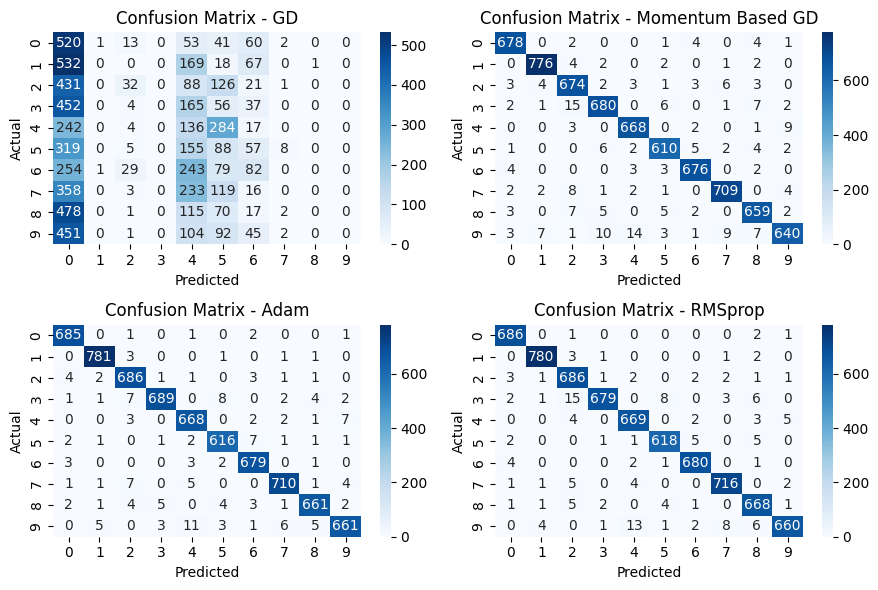

In [ ]:
import seaborn as sns

def show_cm(models):

    plt.figure(figsize=(9, 6))

    for i, (name, model) in enumerate(models.items(), 1):

        pred = np.argmax(model.predict(X_test, verbose=0),axis=1)
        cm = confusion_matrix(y_test, pred)
        plt.subplot(2, 2, i)

        sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
                    xticklabels=range(10),yticklabels=range(10))
        plt.title("Confusion Matrix - " + name)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

show_cm(models)